<a href="https://colab.research.google.com/github/Kamindumenula/SE4050-Household-Waste-Classification-System/blob/main/comparisons/comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
!apt-get install -y git-lfs > /dev/null
!git lfs install > /dev/null

In [3]:
REPO_DIR = "SE4050-Household-Waste-Classification-System"
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Kamindumenula/SE4050-Household-Waste-Classification-System.git
    # Pull the 98 MB Git LFS binary file for ResNet50
    !cd {REPO_DIR} && git lfs pull
else:
    # If folder already exists in Colab, ensure LFS files are pulled
    !cd {REPO_DIR} && git lfs pull

DATASET_DIR = "/content/dataset-resized"
if not os.path.exists(DATASET_DIR):
    !unzip -q -o {REPO_DIR}/dataset/archive.zip -d /content/


IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42


Cloning into 'SE4050-Household-Waste-Classification-System'...
remote: Enumerating objects: 296, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (169/169), done.
remote: Total 296 (delta 105), reused 120 (delta 50), pack-reused 75 (from 1)
Receiving objects: 100% (296/296), 83.66 MiB | 21.41 MiB/s, done.
Resolving deltas: 100% (117/117), done.


In [4]:
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_size = int(len(val_test_ds) * 0.5)
test_ds = val_test_ds.skip(val_size)
class_names = sorted(os.listdir(DATASET_DIR))
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
MODEL_SPECS = {
    "Custom CNN": {
        "path": f"{REPO_DIR}/models/baseline_cnn.keras",
        "type": "Custom Baseline"
    },
    "MobileNetV2": {
        "path": f"{REPO_DIR}/models/mobilenetv2_final.keras",
        "type": "Transfer Learning"
    },
    "ResNet50": {
        "path": f"{REPO_DIR}/models/IT23293908ResNet50.keras",
        "type": "Deep Residuals"
    },
    "EfficientNetB0": {
        "path": f"{REPO_DIR}/models/efficientnetb0_final.keras",
        "type": "Compound Scaling"
    }
}

os.makedirs("results", exist_ok=True)
results_summary = []
model_preds = {}
model_probs = {}
ground_truth_labels = []

# Extract ground-truth labels once
for _, labels in test_ds:
    ground_truth_labels.extend(labels.numpy())
ground_truth_labels = np.array(ground_truth_labels)
y_true_bin = label_binarize(ground_truth_labels, classes=list(range(num_classes)))


**Model Evaluation**

In [6]:
print("\n" + "="*70)
print("RUNNING BENCHMARK EVALUATIONS ON UNSEEN TEST DATA")
print("="*70)

for name, meta in MODEL_SPECS.items():
    if not os.path.exists(meta["path"]):
        print(f"[WARN] File not found: {meta['path']}. Skipping...")
        continue

    print(f"\n--> Evaluating {name}...")
    try:
        model = tf.keras.models.load_model(meta["path"])
    except Exception as e:
        print(f"[ERROR] Failed to load model {name} from {meta['path']}: {e}. Skipping...")
        continue

    total_params = model.count_params()
    size_mb = os.path.getsize(meta["path"]) / (1024 * 1024)

    # Measure latency & predict batch-by-batch
    start_time = time.time()
    all_probs = []

    for images, _ in test_ds:
        p = model.predict(images, verbose=0)
        all_probs.extend(p)

    latency_ms = ((time.time() - start_time) / len(ground_truth_labels)) * 1000

    all_probs = np.array(all_probs)
    all_preds = np.argmax(all_probs, axis=1)

    model_preds[name] = all_preds
    model_probs[name] = all_probs

    # Calculate classification metrics
    report = classification_report(
        ground_truth_labels,
        all_preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )
    acc = report["accuracy"] * 100
    precision = report["weighted avg"]["precision"] * 100
    recall = report["weighted avg"]["recall"] * 100
    f1 = report["weighted avg"]["f1-score"] * 100

    results_summary.append({
        "Model Name": name,
        "Architecture": meta["type"],
        "Parameters": f"{total_params:,}",
        "Size (MB)": f"{size_mb:.1f} MB",
        "Accuracy (%)": round(acc, 2),
        "Precision (%)": round(precision, 2),
        "Recall (%)": round(recall, 2),
        "F1-Score (%)": round(f1, 2),
        "Avg Latency (ms)": round(latency_ms, 2)
    })


RUNNING BENCHMARK EVALUATIONS ON UNSEEN TEST DATA

--> Evaluating Custom CNN...

--> Evaluating MobileNetV2...

--> Evaluating ResNet50...



--> Evaluating EfficientNetB0...


**Final Metrics table**

In [7]:
df_results = pd.DataFrame(results_summary)
print("\n" + "="*70)
print("FINAL METRICS COMPARISON TABLE")
print("="*70)
display(df_results)
df_results.to_csv("results/final_model_comparison.csv", index=False)



FINAL METRICS COMPARISON TABLE


,Model Name,Architecture,Parameters,Size (MB),Accuracy (%),Precision (%),Recall (%),F1-Score (%),Avg Latency (ms)
0,Custom CNN,Custom Baseline,"424,006",4.9 MB,74.30,95.36,74.30,83.52,19.78
1,MobileNetV2,Transfer Learning,"2,265,670",20.8 MB,76.71,92.83,76.71,83.35,20.66
2,ResNet50,Deep Residuals,"23,850,758",93.6 MB,87.15,98.29,87.15,92.28,26.86
3,EfficientNetB0,Compound Scaling,"4,057,257",16.3 MB,89.56,97.81,89.56,93.50,141.81


**Comparison Bar charts**

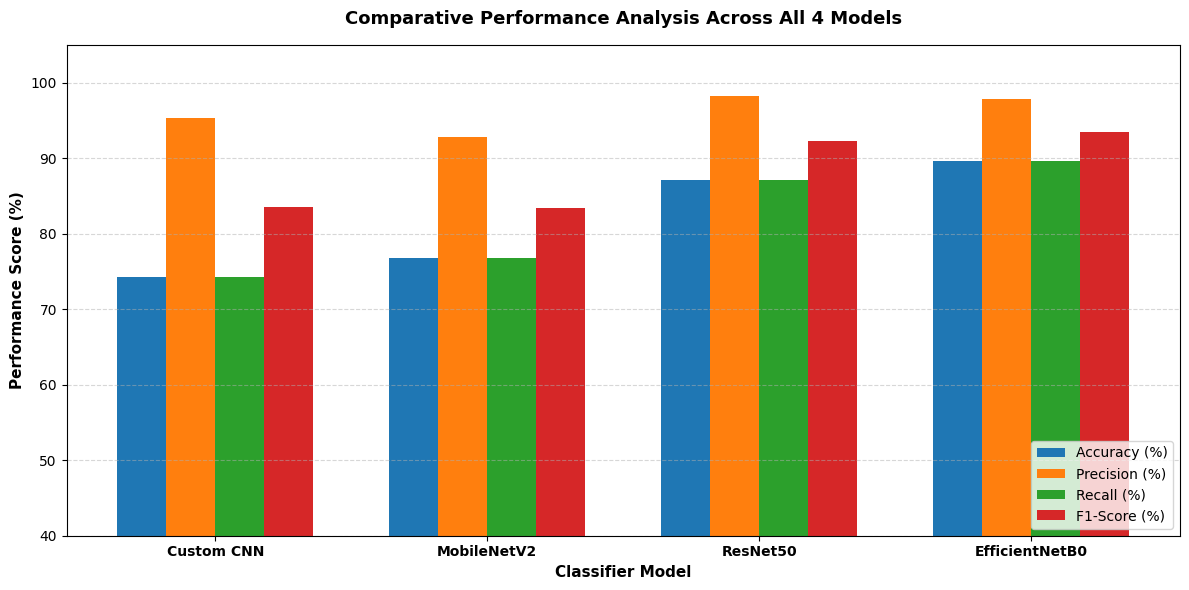

In [8]:
plt.figure(figsize=(12, 6))
metrics = ["Accuracy (%)", "Precision (%)", "Recall (%)", "F1-Score (%)"]
x = np.arange(len(df_results["Model Name"]))
width = 0.18

for i, metric in enumerate(metrics):
    plt.bar(x + (i - 1.5) * width, df_results[metric], width, label=metric)

plt.xlabel("Classifier Model", fontweight="bold", fontsize=11)
plt.ylabel("Performance Score (%)", fontweight="bold", fontsize=11)
plt.title("Comparative Performance Analysis Across All 4 Models", fontweight="bold", fontsize=13, pad=15)
plt.xticks(x, df_results["Model Name"], fontweight="bold")
plt.ylim(40, 105)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/model_performance_comparison.png", dpi=300)
plt.show()

**ROC Curves**

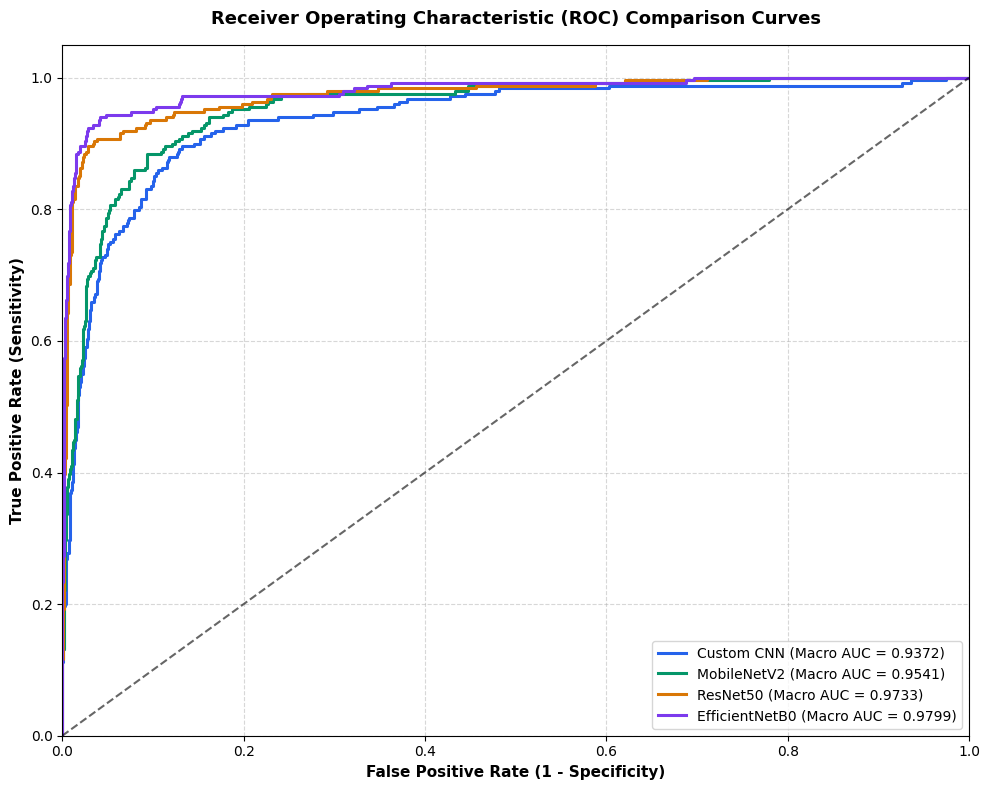

In [9]:
plt.figure(figsize=(10, 8))
colors = ["#2563EB", "#059669", "#D97706", "#7C3AED"]

for idx, (name, probs) in enumerate(model_probs.items()):
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2.2, label=f"{name} (Macro AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.6)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)", fontweight="bold", fontsize=11)
plt.ylabel("True Positive Rate (Sensitivity)", fontweight="bold", fontsize=11)
plt.title("Receiver Operating Characteristic (ROC) Comparison Curves", fontweight="bold", fontsize=13, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("results/roc_curves_comparison.png", dpi=300)
plt.show()

**Accuracy vs Latency graph**

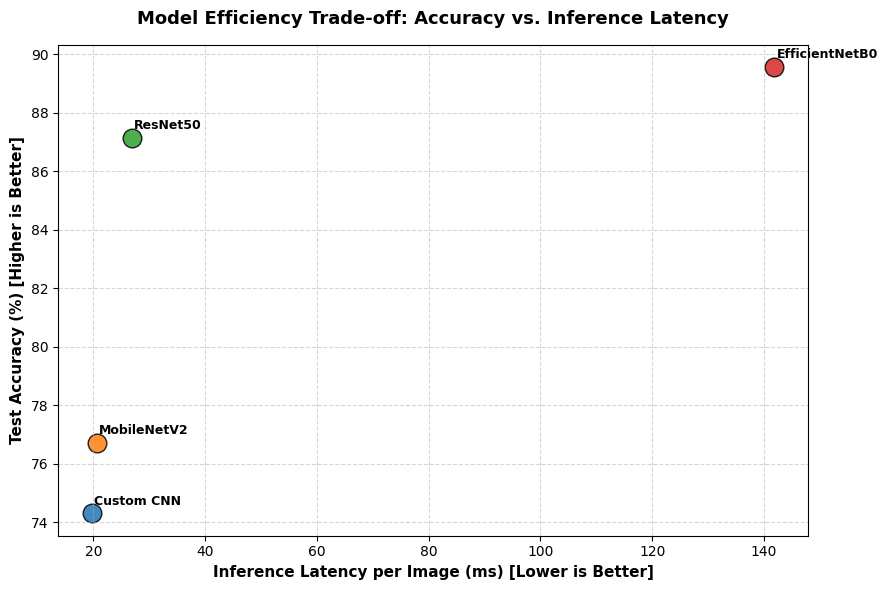

In [10]:
plt.figure(figsize=(9, 6))
for _, row in df_results.iterrows():
    plt.scatter(row["Avg Latency (ms)"], row["Accuracy (%)"], s=180, edgecolors="black", alpha=0.85, label=row["Model Name"])
    plt.text(row["Avg Latency (ms)"] + 0.4, row["Accuracy (%)"] + 0.3, row["Model Name"], fontweight="bold", fontsize=9)

plt.xlabel("Inference Latency per Image (ms) [Lower is Better]", fontweight="bold", fontsize=11)
plt.ylabel("Test Accuracy (%) [Higher is Better]", fontweight="bold", fontsize=11)
plt.title("Model Efficiency Trade-off: Accuracy vs. Inference Latency", fontweight="bold", fontsize=13, pad=15)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("results/accuracy_vs_latency_tradeoff.png", dpi=300)
plt.show()